# Function 1 - Non-Linear Logistic Regression (Week 9)

This notebook:
1. Loads Function 1 data (initial + weeks 1–8)
2. Visualizes all weeks' points
3. Applies Non-Linear Logistic Regression
4. Suggests the next point closest to the decision boundary

## Step 0: Import Packages

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.metrics import mean_squared_error, log_loss

import sys
sys.path.append('../..')  # Go up two levels to project root

import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_2d_scatter_with_distribution
)

import scripts.logistic_regression.nonlinear_logistic_regression as nonlinear_logistic_regression
importlib.reload(nonlinear_logistic_regression)
from scripts.logistic_regression import NonLinearLogisticRegression, make_binary_labels

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Load Data for Function 1

In [16]:
# Load initial data and weeks 1–8
base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')
week7_dir = Path('../../data/week7')
week8_dir = Path('../../data/week8')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')
week7_data = _load_latest_week_data(week7_dir, 'Week 7')
week8_data = _load_latest_week_data(week8_dir, 'Week 8')

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")

Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


## Step 2: Prepare Function 1 Data

In [17]:
function_name = 'function_1'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get week 1–8 data
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']
week7_input = week7_data[function_name]['input']
week7_output = week7_data[function_name]['output']
week8_input = week8_data[function_name]['input']
week8_output = week8_data[function_name]['output']

# Combine initial + weeks 1–8
X_all = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
    week7_input.reshape(1, -1),
    week8_input.reshape(1, -1)
])

y_raw = np.concatenate([
    original_outputs,
    np.array([week1_output, week2_output, week3_output, week4_output, week5_output, week6_output, week7_output, week8_output])
])

print("="*60)
print(f"FUNCTION 1 - COMBINED DATA (Initial + Weeks 1–8)")
print("="*60)
print(f"Combined inputs shape: {X_all.shape}")
print(f"Combined outputs shape: {y_raw.shape}")
print(f"\nInput range: [{X_all.min():.3f}, {X_all.max():.3f}]")
print(f"Output range: [{y_raw.min():.6e}, {y_raw.max():.6e}]")
print("="*60)

FUNCTION 1 - COMBINED DATA (Initial + Weeks 1–8)
Combined inputs shape: (18, 2)
Combined outputs shape: (18,)

Input range: [0.000, 0.884]
Output range: [-3.606063e-03, 2.555929e-02]


## Step 3: Visualize the Data

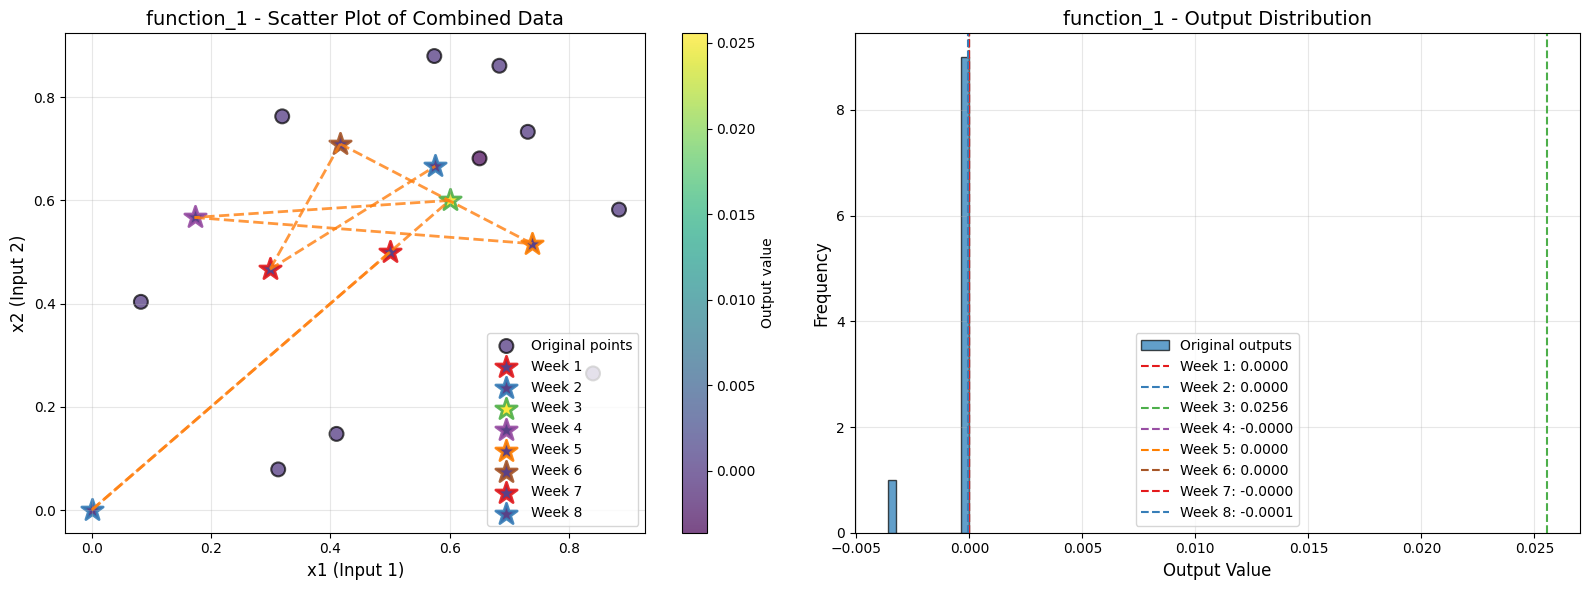

In [18]:
# Visualise all weeks 1–8 points (like function5_local_trust_region_bo)
plot_2d_scatter_with_distribution(
    original_inputs, original_outputs,
    week8_input, week8_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
        (week6_input, week6_output, "Week 6"),
        (week7_input, week7_output, "Week 7"),
        (week8_input, week8_output, "Week 8"),
    ],
    connect_points=True,
    connect_color="tab:orange"
)

## Step 4: Hyperparameter Tuning for Non-Linear Logistic Regression

We'll tune:
- `degree`: Polynomial degree (1, 2, 3) - controls non-linearity
- `threshold_percentile`: For creating binary labels (50, 60, 70, 75, 80, 90)
- `penalty`: Regularization type ('l2')
- `C`: Inverse regularization strength (0.01, 0.1, 1.0, 10.0, 100.0)
- `max_iter`: Maximum iterations (1000, 2000, 5000)

We'll use Mean Squared Error (MSE) on the predicted probabilities vs. binary targets.

In [19]:
# Define hyperparameter grid
degrees = [1, 2, 3]
threshold_percentiles = [50, 60, 70, 75, 80, 90]
penalties = ['l2']
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
max_iters = [1000, 2000, 5000]

results = []

print("Starting hyperparameter tuning for NON-LINEAR logistic regression...")
total_combos = len(degrees) * len(threshold_percentiles) * len(penalties) * len(C_values) * len(max_iters)
print(f"Total combinations: {total_combos}")
print("="*80)

for degree in degrees:
    for threshold_percentile in threshold_percentiles:
        Y, threshold_used = make_binary_labels(y_raw, threshold_percentile=threshold_percentile)
        if np.unique(Y).size < 2:
            continue
        class_balance = f"{(Y == 0).sum()}/{(Y == 1).sum()}"
        for penalty in penalties:
            for max_iter in max_iters:
                for C in C_values:
                    try:
                        nl_log_reg = NonLinearLogisticRegression(
                            degree=degree,
                            penalty=penalty,
                            C=C,
                            random_state=RANDOM_STATE,
                            max_iter=max_iter,
                            solver='lbfgs'
                        )
                        nl_log_reg.fit(X_all, Y)
                        Y_pred = nl_log_reg.predict(X_all)
                        Y_pred_proba = nl_log_reg.predict_proba(X_all)[:, 1]
                        accuracy = nl_log_reg.accuracy(Y, Y_pred)
                        mse = mean_squared_error(Y, Y_pred_proba)
                        logloss = log_loss(Y, Y_pred_proba)
                        results.append({
                            'degree': degree,
                            'threshold_percentile': threshold_percentile,
                            'threshold_value': threshold_used,
                            'class_balance': class_balance,
                            'penalty': penalty,
                            'C': C,
                            'max_iter': max_iter,
                            'mse': mse,
                            'accuracy': accuracy,
                            'log_loss': logloss
                        })
                    except Exception as e:
                        pass

results_df = pd.DataFrame(results)
print(f"Completed. Valid results: {len(results_df)}")

Starting hyperparameter tuning for NON-LINEAR logistic regression...
Total combinations: 270
Completed. Valid results: 270


## Step 5: Analyze Results

In [20]:
results_sorted = results_df.sort_values('mse')

print("\n" + "="*80)
print("TOP 10 MODELS BY MSE")
print("="*80)
print(results_sorted.head(10).to_string(index=False))

print("\n" + "="*80)
print("TOP 10 MODELS BY ACCURACY")
print("="*80)
print(results_df.sort_values('accuracy', ascending=False).head(10).to_string(index=False))

print("\n" + "="*80)
print("COMPARISON BY POLYNOMIAL DEGREE")
print("="*80)
degree_comparison = results_df.groupby('degree').agg({
    'mse': ['mean', 'min', 'std'],
    'accuracy': ['mean', 'max', 'std'],
    'log_loss': ['mean', 'min', 'std']
}).round(6)
print(degree_comparison)


TOP 10 MODELS BY MSE
 degree  threshold_percentile  threshold_value class_balance penalty     C  max_iter      mse  accuracy  log_loss
      3                    90     8.025869e-10          16/2      l2 100.0      5000 0.007110       1.0  0.041770
      3                    90     8.025869e-10          16/2      l2 100.0      1000 0.007110       1.0  0.041770
      3                    90     8.025869e-10          16/2      l2 100.0      2000 0.007110       1.0  0.041770
      2                    90     8.025869e-10          16/2      l2 100.0      1000 0.009571       1.0  0.048072
      2                    90     8.025869e-10          16/2      l2 100.0      2000 0.009571       1.0  0.048072
      2                    90     8.025869e-10          16/2      l2 100.0      5000 0.009571       1.0  0.048072
      3                    80     6.775896e-19          14/4      l2 100.0      2000 0.019709       1.0  0.090509
      3                    80     6.775896e-19          14/4      

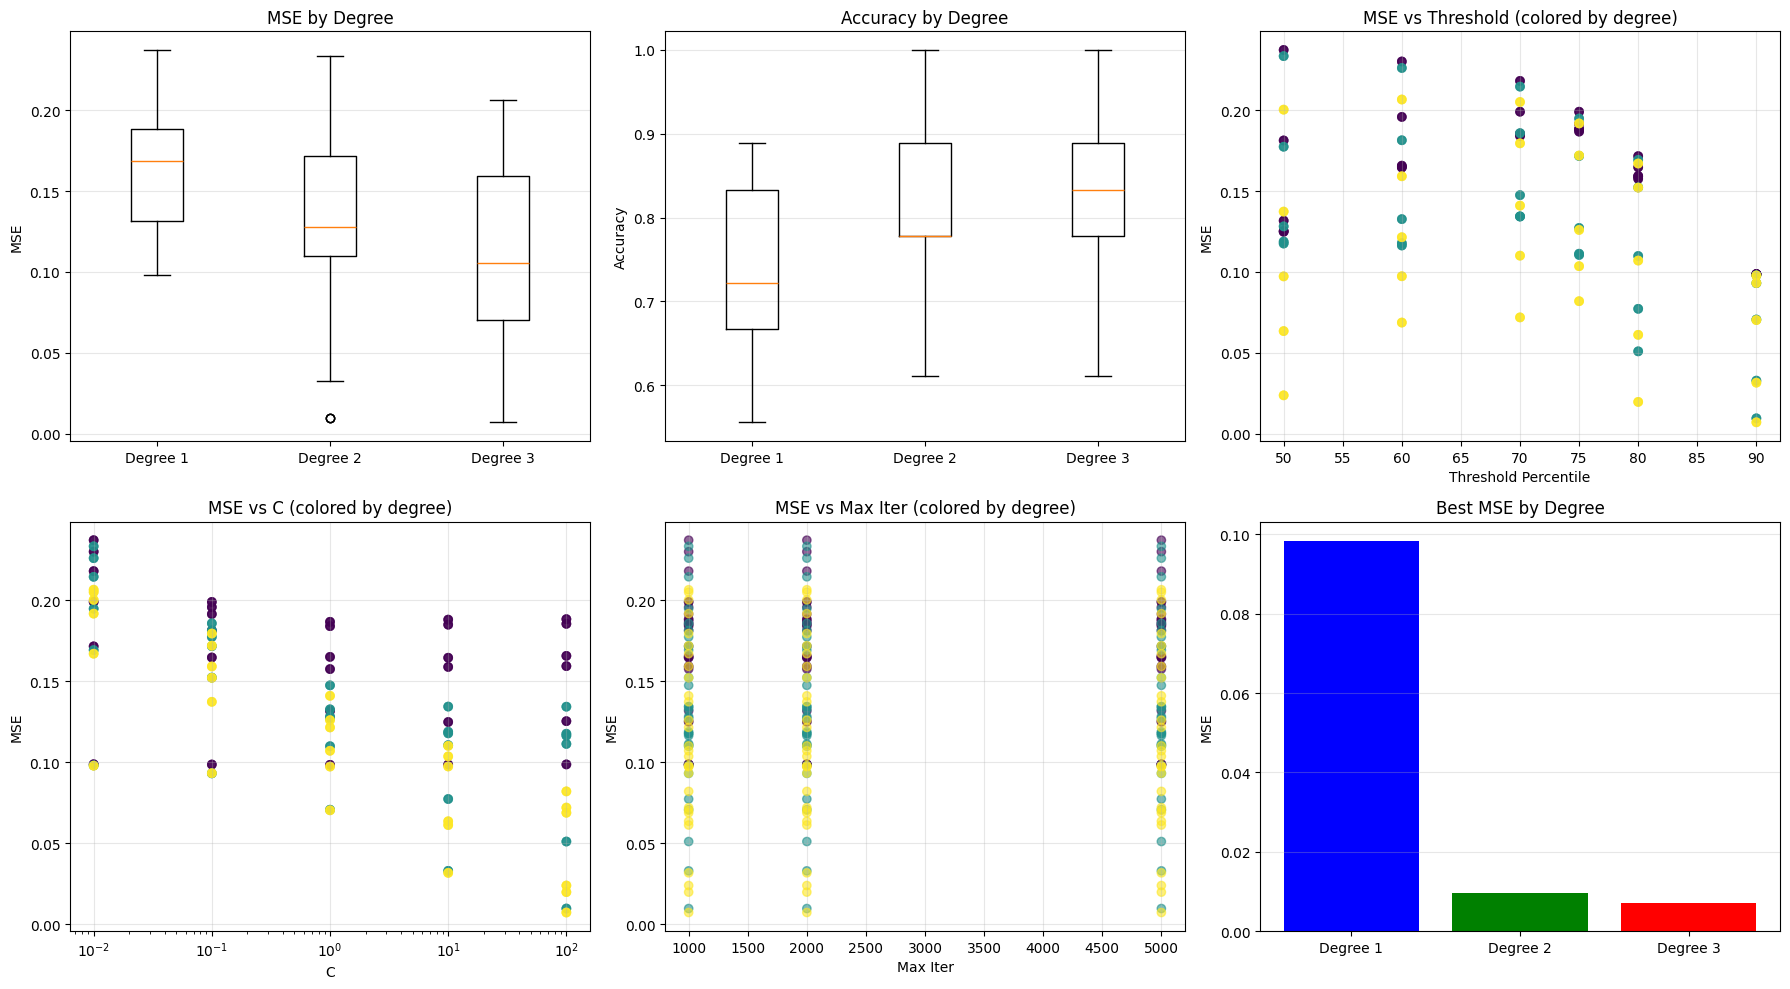

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

degree_groups = results_df.groupby('degree')['mse'].apply(list)
axes[0, 0].boxplot([degree_groups[d] for d in sorted(degree_groups.index)],
                    tick_labels=[f'Degree {d}' for d in sorted(degree_groups.index)])
axes[0, 0].set_ylabel('MSE')
axes[0, 0].set_title('MSE by Degree')
axes[0, 0].grid(True, alpha=0.3, axis='y')

degree_acc = results_df.groupby('degree')['accuracy'].apply(list)
axes[0, 1].boxplot([degree_acc[d] for d in sorted(degree_acc.index)],
                   tick_labels=[f'Degree {d}' for d in sorted(degree_acc.index)])
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy by Degree')
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[0, 2].scatter(results_df['threshold_percentile'], results_df['mse'],
                   c=results_df['degree'], cmap='viridis', alpha=0.6)
axes[0, 2].set_xlabel('Threshold Percentile')
axes[0, 2].set_ylabel('MSE')
axes[0, 2].set_title('MSE vs Threshold (colored by degree)')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].scatter(results_df['C'], results_df['mse'],
                   c=results_df['degree'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('C')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('MSE vs C (colored by degree)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(results_df['max_iter'], results_df['mse'],
                   c=results_df['degree'], cmap='viridis', alpha=0.6)
axes[1, 1].set_xlabel('Max Iter')
axes[1, 1].set_ylabel('MSE')
axes[1, 1].set_title('MSE vs Max Iter (colored by degree)')
axes[1, 1].grid(True, alpha=0.3)

best_by_degree = results_df.loc[results_df.groupby('degree')['mse'].idxmin()]
axes[1, 2].bar([f'Degree {d}' for d in best_by_degree['degree']],
                best_by_degree['mse'], color=['blue', 'green', 'red'])
axes[1, 2].set_ylabel('MSE')
axes[1, 2].set_title('Best MSE by Degree')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 6: Train Best Model

In [22]:
best_params = results_sorted.iloc[0]

print("="*80)
print("BEST MODEL PARAMETERS (by MSE)")
print("="*80)
for key, value in best_params.items():
    print(f"{key:25s}: {value}")
print("="*80)

Y_best, threshold_best = make_binary_labels(
    y_raw,
    threshold_percentile=int(best_params['threshold_percentile'])
)

best_nl_log_reg = NonLinearLogisticRegression(
    degree=int(best_params['degree']),
    penalty=best_params['penalty'],
    C=best_params['C'],
    random_state=RANDOM_STATE,
    max_iter=int(best_params['max_iter']),
    solver='lbfgs'
)

best_nl_log_reg.fit(X_all, Y_best)

if best_params['degree'] > 1:
    feature_names = best_nl_log_reg.get_polynomial_feature_names(['x1', 'x2'])
    print(f"\nPolynomial features (degree={int(best_params['degree'])}): {len(feature_names)} features")

print("\n✓ Best non-linear model trained successfully!")

BEST MODEL PARAMETERS (by MSE)
degree                   : 3
threshold_percentile     : 90
threshold_value          : 8.025869370835339e-10
class_balance            : 16/2
penalty                  : l2
C                        : 100.0
max_iter                 : 5000
mse                      : 0.007110036105307995
accuracy                 : 1.0
log_loss                 : 0.0417697495696229

Polynomial features (degree=3): 10 features

✓ Best non-linear model trained successfully!


## Step 7: Predict Next Point Closest to Decision Boundary

In [23]:
bounds = [[0.0, 1.0], [0.0, 1.0]]

print("="*80)
print("FINDING NEXT POINT CLOSEST TO DECISION BOUNDARY")
print("="*80)

next_point_grid, uncertainty_grid, prob_grid = best_nl_log_reg.find_next_point_near_boundary(
    bounds=bounds, method='grid_search', n_candidates=10000, random_state=RANDOM_STATE
)
print(f"Grid search:  {next_point_grid} (prob={prob_grid:.6f})")

next_point_random, uncertainty_random, prob_random = best_nl_log_reg.find_next_point_near_boundary(
    bounds=bounds, method='random', n_candidates=10000, random_state=RANDOM_STATE
)
print(f"Random search: {next_point_random} (prob={prob_random:.6f})")

next_point_opt, uncertainty_opt, prob_opt = best_nl_log_reg.find_next_point_near_boundary(
    bounds=bounds, method='optimize', random_state=RANDOM_STATE
)
print(f"Optimization:  {next_point_opt} (prob={prob_opt:.6f})")

print("="*80)
print(f"RECOMMENDED NEXT POINT: {next_point_opt}")
print("="*80)

FINDING NEXT POINT CLOSEST TO DECISION BOUNDARY
Grid search:  [0.51515152 0.25252525] (prob=0.498918)
Random search: [0.56553891 0.63730483] (prob=0.499844)
Optimization:  [0.3768393 0.4947996] (prob=0.500000)
RECOMMENDED NEXT POINT: [0.3768393 0.4947996]


## Step 7.5: Class Assignments for All Points

In [24]:
print("="*80)
print("CLASS ASSIGNMENTS")
print("="*80)
print(f"Threshold: {threshold_best:.6e}")
print(f"Class 0: {(Y_best == 0).sum()} points, Class 1: {(Y_best == 1).sum()} points\n")

class_df = pd.DataFrame({
    'Point': range(len(X_all)),
    'x1': X_all[:, 0], 'x2': X_all[:, 1],
    'Output': y_raw, 'Class': Y_best
})
print(class_df.to_string(index=False))
print("="*80)

CLASS ASSIGNMENTS
Threshold: 8.025869e-10
Class 0: 16 points, Class 1: 2 points

 Point       x1       x2        Output  Class
     0 0.319404 0.762959  1.322677e-79      0
     1 0.574329 0.879898  1.033078e-46      0
     2 0.731024 0.733000  7.710875e-16      0
     3 0.840353 0.264732 3.341771e-124      0
     4 0.650114 0.681526 -3.606063e-03      0
     5 0.410437 0.147554 -2.159249e-54      0
     6 0.312691 0.078723 -2.089093e-91      0
     7 0.683418 0.861057  2.535001e-40      0
     8 0.082507 0.403488  3.606771e-81      0
     9 0.883890 0.582254  6.229856e-48      0
    10 0.500000 0.500000  2.675288e-09      1
    11 0.000000 0.000000 2.308811e-248      0
    12 0.600000 0.600000  2.555929e-02      1
    13 0.172410 0.567040 -1.147040e-58      0
    14 0.738068 0.516236  1.129316e-18      0
    15 0.416666 0.709540  2.048903e-36      0
    16 0.298847 0.466448 -6.072986e-14      0
    17 0.575963 0.666474 -6.505255e-05      0


## Step 8: Visualize Decision Boundary and Next Point

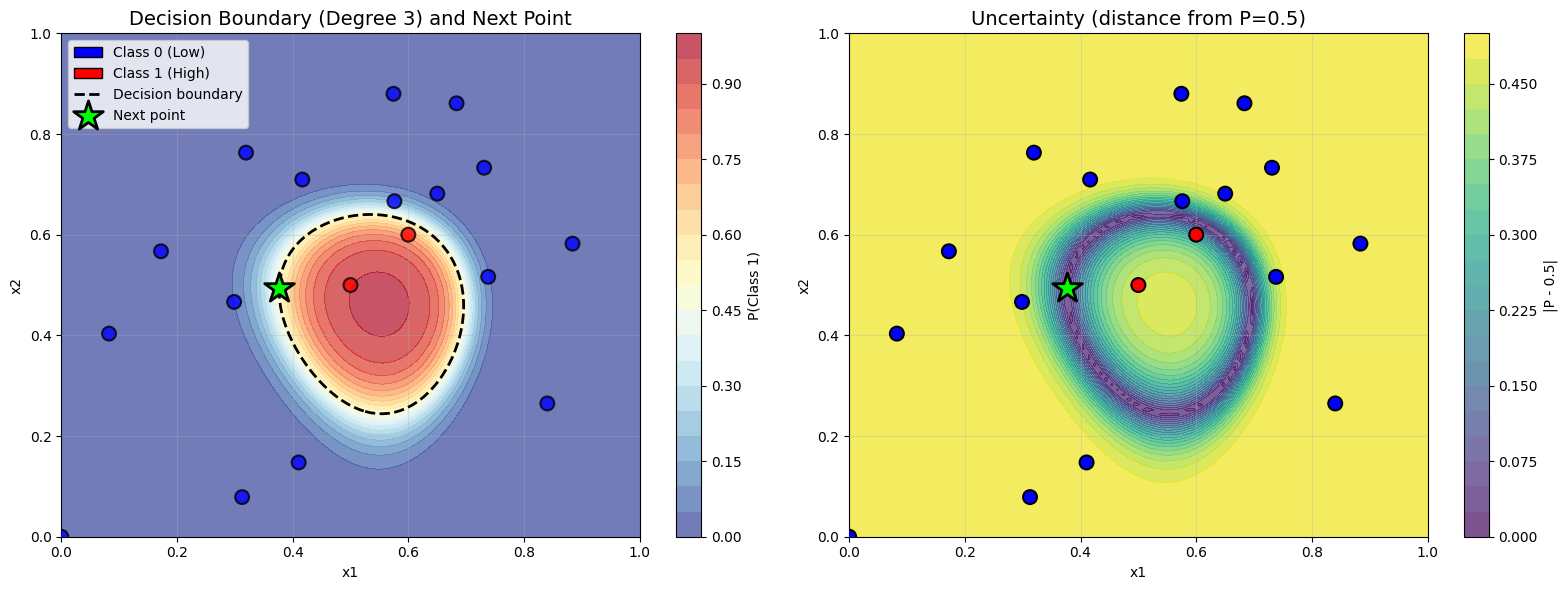

In [25]:
n_grid = 100
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
probs_grid = best_nl_log_reg.predict_proba(grid_points)[:, 1].reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
contour = ax.contourf(X1_grid, X2_grid, probs_grid, levels=20, cmap='RdYlBu_r', alpha=0.7)
ax.contour(X1_grid, X2_grid, probs_grid, levels=[0.5], colors='black', linewidths=2, linestyles='--')
colors_class = ['blue' if y == 0 else 'red' for y in Y_best]
ax.scatter(X_all[:, 0], X_all[:, 1], c=colors_class, s=100, edgecolors='black', linewidths=1.5, zorder=5, alpha=0.8)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Class 0 (Low)'),
    Patch(facecolor='red', edgecolor='black', label='Class 1 (High)'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Decision boundary'),
]
star = ax.scatter(next_point_opt[0], next_point_opt[1], c='lime', marker='*', s=500, edgecolors='black', linewidths=2, zorder=10, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title(f'Decision Boundary (Degree {int(best_params["degree"])}) and Next Point', fontsize=14)
ax.legend(handles=legend_elements + [star], loc='best')
ax.grid(True, alpha=0.3)
plt.colorbar(contour, ax=ax, label='P(Class 1)')

ax = axes[1]
uncertainties_grid = np.abs(probs_grid - 0.5)
contour_unc = ax.contourf(X1_grid, X2_grid, uncertainties_grid, levels=20, cmap='viridis', alpha=0.7)
ax.scatter(X_all[:, 0], X_all[:, 1], c=colors_class, s=100, edgecolors='black', linewidths=1.5, zorder=5)
ax.scatter(next_point_opt[0], next_point_opt[1], c='lime', marker='*', s=500, edgecolors='black', linewidths=2, zorder=10)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Uncertainty (distance from P=0.5)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.colorbar(contour_unc, ax=ax, label='|P - 0.5|')
plt.tight_layout()
plt.show()

## Step 8.5: Inputs and Outputs Comparison Table

Table below: **Input number** (1 = first initial, …, then +1 per week), **Output value**, **Distance to maximum input** (Euclidean distance to the input with the highest output), and **Summary of progress** (Improving / Not improving vs the previous week; we want to maximise output). Reusable across functions and weeks via `make_inputs_outputs_table(X, y, n_initial)` in `scripts.utils.distance_utils`.

In [26]:
# Reusable across functions: set n_initial for this function (Function 1 = 10 initial points)
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

n_initial_function1 = original_inputs.shape[0]  # 10 for Function 1
# Proposed week 8: use recommended next point; estimated output = predicted probability (proxy for this classifier)
y_proposed_week9 = best_nl_log_reg.predict_proba(next_point_opt.reshape(1, -1))[0, 1]
table = make_inputs_outputs_table(
    X_all, y_raw, n_initial_function1,
    x_proposed=next_point_opt,
    y_proposed=y_proposed_week9,
)
display(table)

,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,1.322677e-79,0.324484,Initial
1,initial,2,1.033078e-46,0.281073,Initial
2,initial,3,7.710875e-16,0.186698,Initial
3,initial,4,3.341771e-124,0.412522,Initial
4,initial,5,-3.606063e-03,0.095697,Initial
5,initial,6,-2.159249e-54,0.490552,Initial
6,initial,7,-2.089093e-91,0.595211,Initial
7,initial,8,2.535001e-40,0.274061,Initial
8,initial,9,3.606771e-81,0.553548,Initial
9,initial,10,6.229856e-48,0.284444,Initial


## Step 9: Summary

In [27]:
print("="*80)
print("SUMMARY - FUNCTION 1 (WEEK 9, DATA: INITIAL + WEEKS 1–8)")
print("="*80)
print(f"Samples: {len(X_all)}, Dimensions: {X_all.shape[1]}")
print(f"Best: degree={best_params['degree']}, threshold_pct={best_params['threshold_percentile']}, C={best_params['C']}")
print(f"MSE: {best_params['mse']:.6f}, Accuracy: {best_params['accuracy']:.4f}")
print(f"Recommended next point: {next_point_opt}")
print("="*80)

SUMMARY - FUNCTION 1 (WEEK 9, DATA: INITIAL + WEEKS 1–8)
Samples: 18, Dimensions: 2
Best: degree=3, threshold_pct=90, C=100.0
MSE: 0.007110, Accuracy: 1.0000
Recommended next point: [0.3768393 0.4947996]


## Step 10: Save Next Point for Submission

In [28]:
import json

Path('results').mkdir(exist_ok=True)
function1_next_point = {
    'function_name': 'function_1',
    'next_point': next_point_opt.tolist(),
    'formatted': '-'.join([f'{x:.6f}' for x in next_point_opt]),
    'method': 'nonlinear_logistic_regression',
    'degree': int(best_params['degree']),
    'data_weeks': ['initial', 'week1', 'week2', 'week3', 'week4', 'week5', 'week6', 'week7', 'week8']
}
with open('results/function1_next_point.json', 'w') as f:
    json.dump(function1_next_point, f, indent=2)
print("Saved to results/function1_next_point.json")
print(f"Formatted: {function1_next_point['formatted']}")

Saved to results/function1_next_point.json
Formatted: 0.376839-0.494800
